# IVS Weekmonitor Analysis & UN/LOCODE Mapping

This notebook demonstrates how to process the IVS weekmonitor data from Rijkswaterstaat, aggregate cargo by origin-destination (OD) pairs, and map these flows to the inland waterway network using ISRS locodes and Zenodo reference data.

In [1]:
import pathlib
import zipfile
import io
import requests
import pickle
import itertools
import logging

import pandas as pd
import geopandas as gpd
import shapely.wkt
import shapely.geometry
import networkx as nx
import matplotlib.pyplot as plt
import contextily as cx
from tqdm.auto import tqdm

# Set up logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

/Users/baart_f/src/fis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load IVS Data Directly from Internet
We fetch the latest weekmonitor ZIP and read the CSV content in-memory.

In [2]:
ivs_url = "https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip"

logger.info(f"Fetching IVS data from {ivs_url}...")
r = requests.get(ivs_url, timeout=30)
r.raise_for_status()

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        ivs_df = pd.read_csv(f, sep=";")

logger.info(f"Loaded {len(ivs_df)} records from {csv_filename}.")
ivs_df.head()

INFO: Fetching IVS data from https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip...


INFO: Loaded 55646 records from IVS_weekmonitor_31MAR2026.csv.


,Jaarmaand,Jaar,Maand,Weeknr,v05_06_Begindt_evenement_iso,v05_06_Begindt_evenement,UNLO_herkomst,UNLO_bestemming,v15_1_Scheepstype_RWS,SK_CODE,v18_Laadvermogen,v28_Beladingscode,v38_Vervoerd_gewicht,v30_4_Containers_TEU_S,nstr_nw,nst2007_nw
0,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,DEFRA,2,M8,2660,7,1303000.0,0,3.0,7.2
1,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,NLAMS,2,M8,3550,7,1030000.0,0,3.0,8.5
2,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLLEY,NLUTC,1,M8,3230,7,514125.0,65,9.0,19.2
3,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLAMS,FRSXB,2,M9,3500,7,2122000.0,0,3.0,7.2
4,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEGNE,BEANR,2,M10,5220,7,2704000.0,0,8.0,8.2


## 2. Aggregate OD Data
We group the cargo data by origin (`UNLO_herkomst`) and destination (`UNLO_bestemming`).

In [3]:
# Filter for Dutch origins and destinations (prefix NL)
nl_mask = ivs_df["UNLO_herkomst"].str.startswith("NL", na=False) & ivs_df[
    "UNLO_bestemming"
].str.startswith("NL", na=False)
ivs_nl = ivs_df[nl_mask].copy()

# Aggregate transported weight (v38_Vervoerd_gewicht) by OD pair
od_pairs = (
    ivs_nl.groupby(["UNLO_herkomst", "UNLO_bestemming"])["v38_Vervoerd_gewicht"]
    .sum()
    .reset_index()
)
od_pairs = od_pairs.sort_values(by="v38_Vervoerd_gewicht", ascending=False)

top_100_od = od_pairs.head(100)
logger.info(
    f"Aggregated top 100 Dutch OD pairs. Total weight of top pair: {top_100_od.iloc[0]['v38_Vervoerd_gewicht']:,} kg"
)
top_100_od.head(10)

INFO: Aggregated top 100 Dutch OD pairs. Total weight of top pair: 1,613,742,622.0 kg


,UNLO_herkomst,UNLO_bestemming,v38_Vervoerd_gewicht
3711,NLRTM,NLAMS,1.613743e+09
305,NLAMS,NLRTM,5.287459e+08
3840,NLRTM,NLRTM,4.868439e+08
3860,NLRTM,NLVLI,2.207039e+08
4525,NLVLI,NLAMS,2.200845e+08
4567,NLVLI,NLRTM,1.995461e+08
3810,NLRTM,NLMOE,1.896690e+08
226,NLAMS,NLGOU,1.536277e+08
176,NLAMS,NLAMS,1.201441e+08
3852,NLRTM,NLTNZ,1.151215e+08


## 3. Load Network and Map UN/LOCODEs
We load the merged graph and map the 5-character UN/LOCODEs to network nodes (specifically `sectionjunction` types).

In [4]:
graph_path = pathlib.Path("../output/merged-graph/graph.pickle")
with graph_path.open("rb") as f:
    graph = pickle.load(f)

nodes_gdf = gpd.GeoDataFrame(graph.nodes.values(), index=graph.nodes.keys())
nodes_gdf = nodes_gdf.set_crs(epsg=4326)
logger.info(f"Loaded network with {len(nodes_gdf)} nodes.")


def get_sample_node_for_locode(locode):
    """Find a representative sectionjunction node for the given 5-char UN/LOCODE."""
    mask = nodes_gdf["locode"].str.startswith(locode, na=False) | nodes_gdf[
        "locode"
    ].str.contains(locode[2:], na=False)
    junction_mask = nodes_gdf["geo_type"] == "sectionjunction"
    matches = nodes_gdf[mask & junction_mask]
    if matches.empty:
        return None
    return matches.index[0]

INFO: Loaded network with 7089 nodes.


## 4. Compute Routes for Top 100
We calculate the shortest path for each of the top 100 OD pairs.

In [5]:
route_geoms = []
success_count = 0

for idx, row in tqdm(
    top_100_od.iterrows(), total=len(top_100_od), desc="Routing top 100"
):
    u_loc = row["UNLO_herkomst"]
    v_loc = row["UNLO_bestemming"]
    weight = row["v38_Vervoerd_gewicht"]

    u_node = get_sample_node_for_locode(u_loc)
    v_node = get_sample_node_for_locode(v_loc)

    if u_node and v_node:
        try:
            route = nx.shortest_path(graph, u_node, v_node, weight="length_m")

            # Extract edges
            for u, v in itertools.pairwise(route):
                edge_data = graph.edges[u, v]
                geom = edge_data.get("geometry")
                if isinstance(geom, str):
                    geom = shapely.wkt.loads(geom)
                if geom:
                    route_geoms.append(
                        {
                            "geometry": geom,
                            "weight": weight,
                            "pair": f"{u_loc}->{v_loc}",
                        }
                    )
            success_count += 1
        except nx.NetworkXNoPath:
            continue

logger.info(f"Successfully routed {success_count} / {len(top_100_od)} pairs.")
all_routes_gdf = gpd.GeoDataFrame(route_geoms, crs="EPSG:4326")

Routing top 100:   0%|                                                                               | 0/100 [00:00<?, ?it/s]

Routing top 100:  34%|███████████████████████▍                                             | 34/100 [00:00<00:00, 337.20it/s]

Routing top 100:  70%|████████████████████████████████████████████████▎                    | 70/100 [00:00<00:00, 349.24it/s]

Routing top 100: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 356.52it/s]


INFO: Successfully routed 93 / 100 pairs.


## 5. Visualize Top 100 Routes
Display all popular routes on a background map.

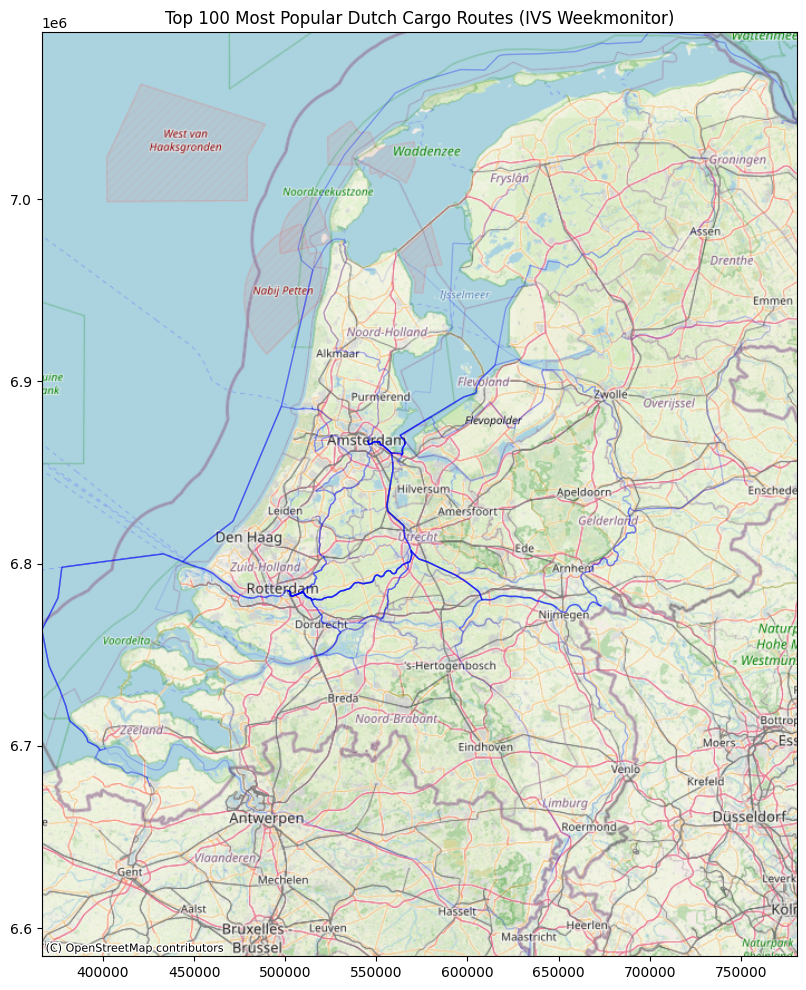

In [6]:
# Convert to Web Mercator
routes_3857 = all_routes_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(15, 12))

# Plot with transparency to show overlap/intensity
routes_3857.plot(
    ax=ax, color="blue", linewidth=1, alpha=0.1, label="Popular Cargo Routes"
)

# Set extent to NL
minx, miny, maxx, maxy = routes_3857.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Add basemap
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_title("Top 100 Most Popular Dutch Cargo Routes (IVS Weekmonitor)")
plt.show()